# AI Credit Risk Prediction

Notebook 4 — Model Training

Author : Owaish Ansari

Purpose:
Train machine learning models on the
final engineered dataset.
 ##

In [1]:
import os
import sys

PROJECT_ROOT = r"C:\Users\Asus\AI_Credit_Risk_Prediction"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project Ready")

Project Ready


In [3]:
from src.database.postgres import load_table, save_table

final_dataset = load_table("final_dataset")

final_dataset Loaded


In [4]:
print(final_dataset.shape)

(307511, 244)


In [5]:
final_dataset.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PAYMENT_BALANCE_RATIO_MEAN,DRAWING_LIMIT_RATIO_MEAN,DPD_MEAN,DPD_MAX,DPD_DEF_MEAN,DPD_DEF_MAX,LATE_COUNT,SEVERE_LATE_COUNT,LATE_RATIO,SEVERE_LATE_RATIO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
print("=" * 60)
print("Target Distribution")
print(final_dataset["TARGET"].value_counts())
print("=" * 60)

Target Distribution
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [8]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 244 entries, SK_ID_CURR to SEVERE_LATE_RATIO
dtypes: float64(187), int64(41), object(16)
memory usage: 572.5+ MB


In [9]:
id_columns = [
    "SK_ID_CURR"
]

X = final_dataset.drop(
    columns=id_columns + ["TARGET"]
)

y = final_dataset["TARGET"]

print(X.shape)
print(y.shape)

(307511, 242)
(307511,)


In [10]:
print(y.value_counts())

print()

print(y.value_counts(normalize=True))

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [1]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

NameError: name 'X' is not defined

In [12]:
print("=" * 60)

print("Training")

print(X_train.shape)

print(y_train.value_counts())

print()

print("Testing")

print(X_test.shape)

print(y_test.value_counts())

print("=" * 60)

Training
(246008, 242)
TARGET
0    226148
1     19860
Name: count, dtype: int64

Testing
(61503, 242)
TARGET
0    56538
1     4965
Name: count, dtype: int64


In [13]:
# Numerical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric Features :", len(numeric_features))
print("Categorical Features :", len(categorical_features))

Numeric Features : 226
Categorical Features : 16


In [14]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [15]:
numeric_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]

)

In [16]:
categorical_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]

)

In [17]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_pipeline,
            numeric_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )

    ]

)

In [26]:
X_train_final = preprocessor.fit_transform(
    X_train
)

X_test_final = preprocessor.transform(
    X_test
)

In [27]:
print("Training Shape")

print(X_train_final.shape)

print()

print("Testing Shape")

print(X_test_final.shape)

Training Shape
(246008, 372)

Testing Shape
(61503, 372)


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model_results = []

def evaluate_model(model, model_name, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Print Results
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))

    # Save Results
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    })

In [36]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_final,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
evaluate_model(
    logistic_model,
    "Logistic Regression",
    X_test_final,
    y_test
)

Logistic Regression
Accuracy  : 0.7000
Precision : 0.1698
Recall    : 0.6985
F1 Score  : 0.2732
ROC AUC   : 0.7641

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.70      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.57      0.70      0.54     61503
weighted avg       0.90      0.70      0.77     61503


Confusion Matrix

[[39587 16951]
 [ 1497  3468]]


In [38]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [40]:
decision_tree.fit(
    X_train_final,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
evaluate_model(
    decision_tree,
    "Decision Tree",
    X_test_final,
    y_test
)

Decision Tree
Accuracy  : 0.8526
Precision : 0.1483
Recall    : 0.1742
F1 Score  : 0.1602
ROC AUC   : 0.5432

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     56538
           1       0.15      0.17      0.16      4965

    accuracy                           0.85     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.85      0.86     61503


Confusion Matrix

[[51572  4966]
 [ 4100   865]]


In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
random_forest = RandomForestClassifier(

    n_estimators=200,

    max_depth=None,

    min_samples_split=2,

    min_samples_leaf=1,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

In [44]:
random_forest.fit(
    X_train_final,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
evaluate_model(
    random_forest,
    "Random Forest",
    X_test_final,
    y_test
)

Random Forest
Accuracy  : 0.9194
Precision : 0.6250
Recall    : 0.0030
F1 Score  : 0.0060
ROC AUC   : 0.7442

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.62      0.00      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.77      0.50      0.48     61503
weighted avg       0.90      0.92      0.88     61503


Confusion Matrix

[[56529     9]
 [ 4950    15]]


In [46]:
import pandas as pd

results = pd.DataFrame(model_results)

results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.700047,0.169842,0.698489,0.273243,0.764149
2,Random Forest,0.919370,0.625000,0.003021,0.006013,0.744151
1,Decision Tree,0.852593,0.148345,0.174220,0.160245,0.543192


In [47]:
from xgboost import XGBClassifier

In [48]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

11.38710976837865


In [49]:
xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="auc",

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    n_jobs=-1
)

In [50]:
xgb_model.fit(
    X_train_final,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [51]:
evaluate_model(
    xgb_model,
    "XGBoost",
    X_test_final,
    y_test
)

XGBoost
Accuracy  : 0.7489
Precision : 0.1917
Recall    : 0.6562
F1 Score  : 0.2967
ROC AUC   : 0.7791

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.76      0.85     56538
           1       0.19      0.66      0.30      4965

    accuracy                           0.75     61503
   macro avg       0.58      0.71      0.57     61503
weighted avg       0.90      0.75      0.80     61503


Confusion Matrix

[[42801 13737]
 [ 1707  3258]]


In [52]:
results = pd.DataFrame(model_results)

results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,XGBoost,0.748890,0.191703,0.656193,0.296721,0.779111
0,Logistic Regression,0.700047,0.169842,0.698489,0.273243,0.764149
2,Random Forest,0.919370,0.625000,0.003021,0.006013,0.744151
1,Decision Tree,0.852593,0.148345,0.174220,0.160245,0.543192


In [54]:
from lightgbm import LGBMClassifier

In [55]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

11.38710976837865


In [73]:
lgbm_model = LGBMClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    num_leaves=31,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary",

    random_state=42,

    n_jobs=-1
)

In [57]:
lgbm_model.fit(
    X_train_final,
    y_train
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.348246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33569
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 359
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [58]:
evaluate_model(
    lgbm_model,
    "LightGBM",
    X_test_final,
    y_test
)

LightGBM
Accuracy  : 0.7333
Precision : 0.1862
Recall    : 0.6836
F1 Score  : 0.2927
ROC AUC   : 0.7803

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.19      0.68      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.71      0.56     61503
weighted avg       0.90      0.73      0.79     61503


Confusion Matrix

[[41705 14833]
 [ 1571  3394]]


In [60]:
import pandas as pd

results = pd.DataFrame(model_results)

results.sort_values(
    by="ROC_AUC",
    ascending=True
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Decision Tree,0.852593,0.148345,0.174220,0.160245,0.543192
2,Random Forest,0.919370,0.625000,0.003021,0.006013,0.744151
0,Logistic Regression,0.700047,0.169842,0.698489,0.273243,0.764149
3,XGBoost,0.748890,0.191703,0.656193,0.296721,0.779111
4,LightGBM,0.733281,0.186207,0.683585,0.292687,0.780313


In [62]:
from catboost import CatBoostClassifier

In [63]:
catboost_model = CatBoostClassifier(

    iterations=300,

    learning_rate=0.05,

    depth=6,

    loss_function="Logloss",

    eval_metric="AUC",

    auto_class_weights="Balanced",

    random_seed=42,

    verbose=100
)

In [64]:
catboost_model.fit(
    X_train_final,
    y_train
)

0:	total: 207ms	remaining: 1m 1s
100:	total: 6.08s	remaining: 12s
200:	total: 11.6s	remaining: 5.72s
299:	total: 17.3s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [65]:
evaluate_model(
    catboost_model,
    "CatBoost",
    X_test_final,
    y_test
)

CatBoost
Accuracy  : 0.7192
Precision : 0.1790
Recall    : 0.6910
F1 Score  : 0.2844
ROC AUC   : 0.7772

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.72      0.83     56538
           1       0.18      0.69      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.71      0.55     61503
weighted avg       0.90      0.72      0.78     61503


Confusion Matrix

[[40805 15733]
 [ 1534  3431]]


In [66]:
import pandas as pd

results = pd.DataFrame(model_results)

results = results.sort_values(
    by="ROC_AUC",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,LightGBM,0.733281,0.186207,0.683585,0.292687,0.780313
3,XGBoost,0.748890,0.191703,0.656193,0.296721,0.779111
5,CatBoost,0.719249,0.179034,0.691037,0.284388,0.777243
0,Logistic Regression,0.700047,0.169842,0.698489,0.273243,0.764149
2,Random Forest,0.919370,0.625000,0.003021,0.006013,0.744151
1,Decision Tree,0.852593,0.148345,0.174220,0.160245,0.543192


In [67]:
from lightgbm import LGBMClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import roc_auc_score

import numpy as np

In [74]:
param_grid = {

    "n_estimators":[200,300],

    "learning_rate":[0.03,0.05],

    "max_depth":[5,6],

    "num_leaves":[31,40]

}

In [69]:
negative = (y_train == 0).sum()

positive = (y_train == 1).sum()

scale_pos_weight = negative / positive


lgbm = LGBMClassifier(

    objective="binary",

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    n_jobs=-1

)

In [75]:
random_search = RandomizedSearchCV(

    estimator=lgbm,

    param_distributions=param_grid,

    n_iter=10,

    cv=3,

    scoring="roc_auc",

    verbose=2,

    random_state=42,

    n_jobs=1

)

In [76]:
random_search.fit(

    X_train_final,

    y_train

)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 13240, number of negative: 150765
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.296029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33420
[LightGBM] [Info] Number of data points in the train set: 164005, number of used features: 359
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,estimator,LGBMClassifie...710976837865))
,param_distributions,"{'learning_rate': [0.03, 0.05], 'max_depth': [5, 6], 'n_estimators': [200, 300], 'num_leaves': [31, 40]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [77]:
print(random_search.best_params_)

print()

print(random_search.best_score_)

{'num_leaves': 31, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}

0.7809636700689392


In [78]:
best_lgbm = random_search.best_estimator_

In [79]:
evaluate_model(

    best_lgbm,

    "LightGBM Tuned",

    X_test_final,

    y_test

)

LightGBM Tuned
Accuracy  : 0.7334
Precision : 0.1859
Recall    : 0.6814
F1 Score  : 0.2921
ROC AUC   : 0.7805

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.19      0.68      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.71      0.56     61503
weighted avg       0.90      0.73      0.79     61503


Confusion Matrix

[[41723 14815]
 [ 1582  3383]]


In [80]:
results = pd.DataFrame(model_results)

results.sort_values(

    by="ROC_AUC",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
6,LightGBM Tuned,0.733395,0.185900,0.681370,0.292104,0.780456
4,LightGBM,0.733281,0.186207,0.683585,0.292687,0.780313
3,XGBoost,0.748890,0.191703,0.656193,0.296721,0.779111
5,CatBoost,0.719249,0.179034,0.691037,0.284388,0.777243
0,Logistic Regression,0.700047,0.169842,0.698489,0.273243,0.764149
2,Random Forest,0.919370,0.625000,0.003021,0.006013,0.744151
1,Decision Tree,0.852593,0.148345,0.174220,0.160245,0.543192


In [81]:

import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)

In [82]:
y_prob = best_lgbm.predict_proba(
    X_test_final
)[:,1]

In [83]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

results = []

In [84]:
for threshold in thresholds:

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    results.append({

        "Threshold": threshold,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1

    })

In [85]:
threshold_results = pd.DataFrame(
    results
)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.151749,0.086407,0.993152,0.158982
1,0.15,0.236964,0.094002,0.978449,0.171524
2,0.20,0.326391,0.103048,0.953273,0.185991
3,0.25,0.411248,0.113295,0.921853,0.201790
4,0.30,0.489748,0.124791,0.884794,0.218731
5,0.35,0.561257,0.137667,0.842497,0.236662
6,0.40,0.624831,0.151227,0.790735,0.253896
7,0.45,0.682633,0.167565,0.738771,0.273171
8,0.50,0.733395,0.185900,0.681370,0.292104
9,0.55,0.776434,0.206364,0.621752,0.309878


In [86]:
best_threshold = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold

Threshold    0.650000
Accuracy     0.848707
Precision    0.258029
Recall       0.466062
F1           0.332161
Name: 11, dtype: float64

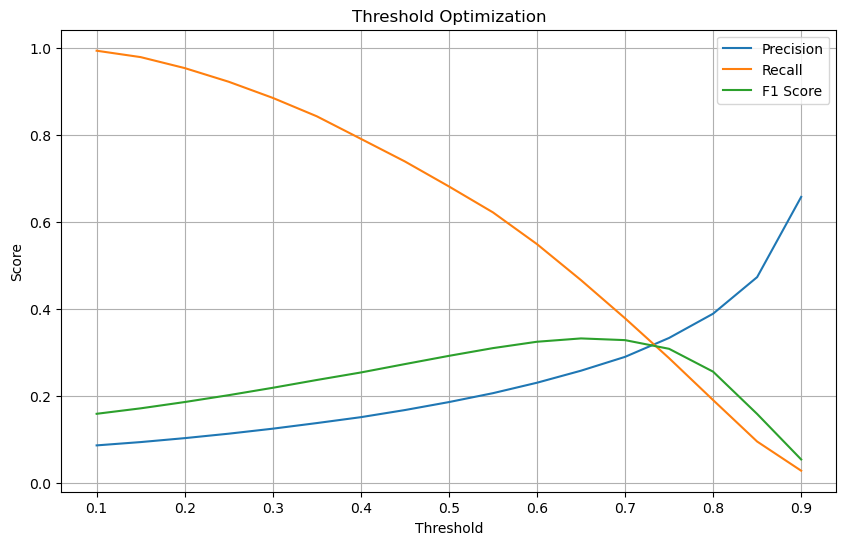

In [87]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1 Score"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.legend()

plt.grid(True)

plt.show()

In [88]:
threshold_results

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.151749,0.086407,0.993152,0.158982
1,0.15,0.236964,0.094002,0.978449,0.171524
2,0.20,0.326391,0.103048,0.953273,0.185991
3,0.25,0.411248,0.113295,0.921853,0.201790
4,0.30,0.489748,0.124791,0.884794,0.218731
5,0.35,0.561257,0.137667,0.842497,0.236662
6,0.40,0.624831,0.151227,0.790735,0.253896
7,0.45,0.682633,0.167565,0.738771,0.273171
8,0.50,0.733395,0.185900,0.681370,0.292104
9,0.55,0.776434,0.206364,0.621752,0.309878


In [89]:
best_threshold_value = 0.65

y_pred_final = (
    y_prob >= best_threshold_value
).astype(int)

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("Final LightGBM Model")
print("=" * 60)

print(f"Threshold : {best_threshold_value}")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_final):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_final))

Final LightGBM Model
Threshold : 0.65
Accuracy  : 0.8487
Precision : 0.2580
Recall    : 0.4661
F1 Score  : 0.3322

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.26      0.47      0.33      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.67      0.62     61503
weighted avg       0.89      0.85      0.87     61503


Confusion Matrix

[[49884  6654]
 [ 2651  2314]]


In [115]:
import pandas as pd

X_sample = pd.DataFrame(
    X_test_final[:500],
    columns=feature_names
)

print(type(X_sample))

<class 'pandas.core.frame.DataFrame'>


In [116]:
import shap

explainer = shap.TreeExplainer(best_lgbm)

In [117]:
shap_values = explainer(X_sample)

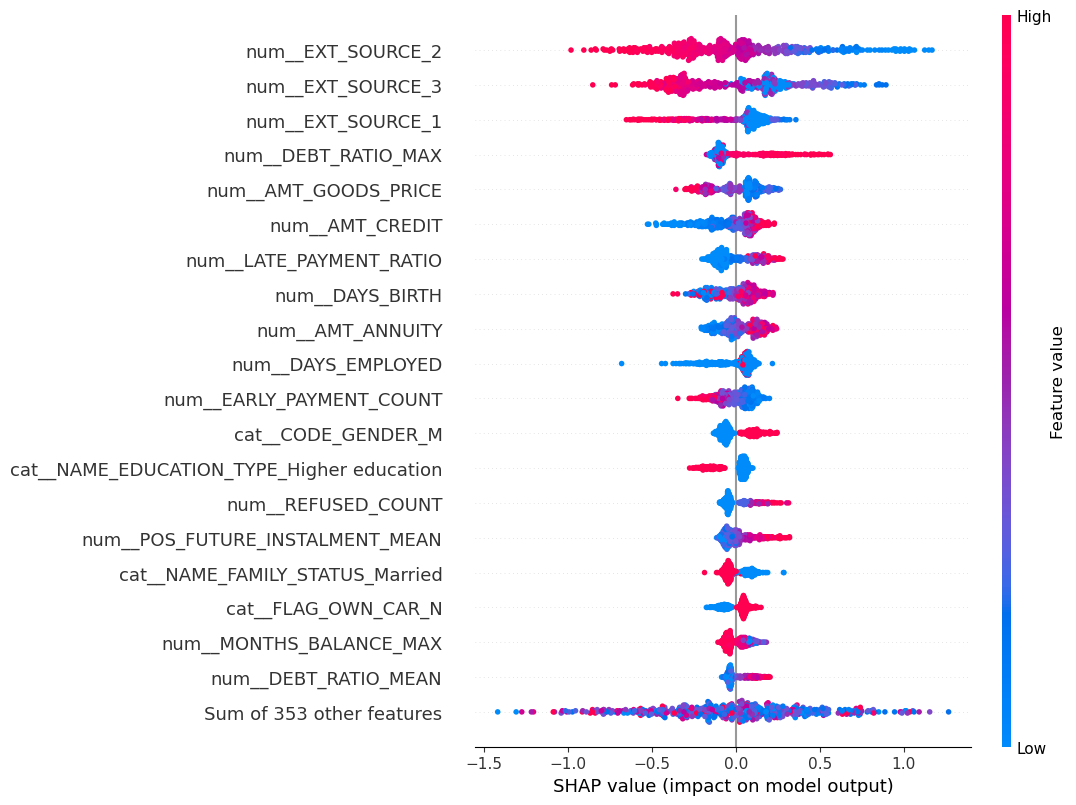

In [118]:
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

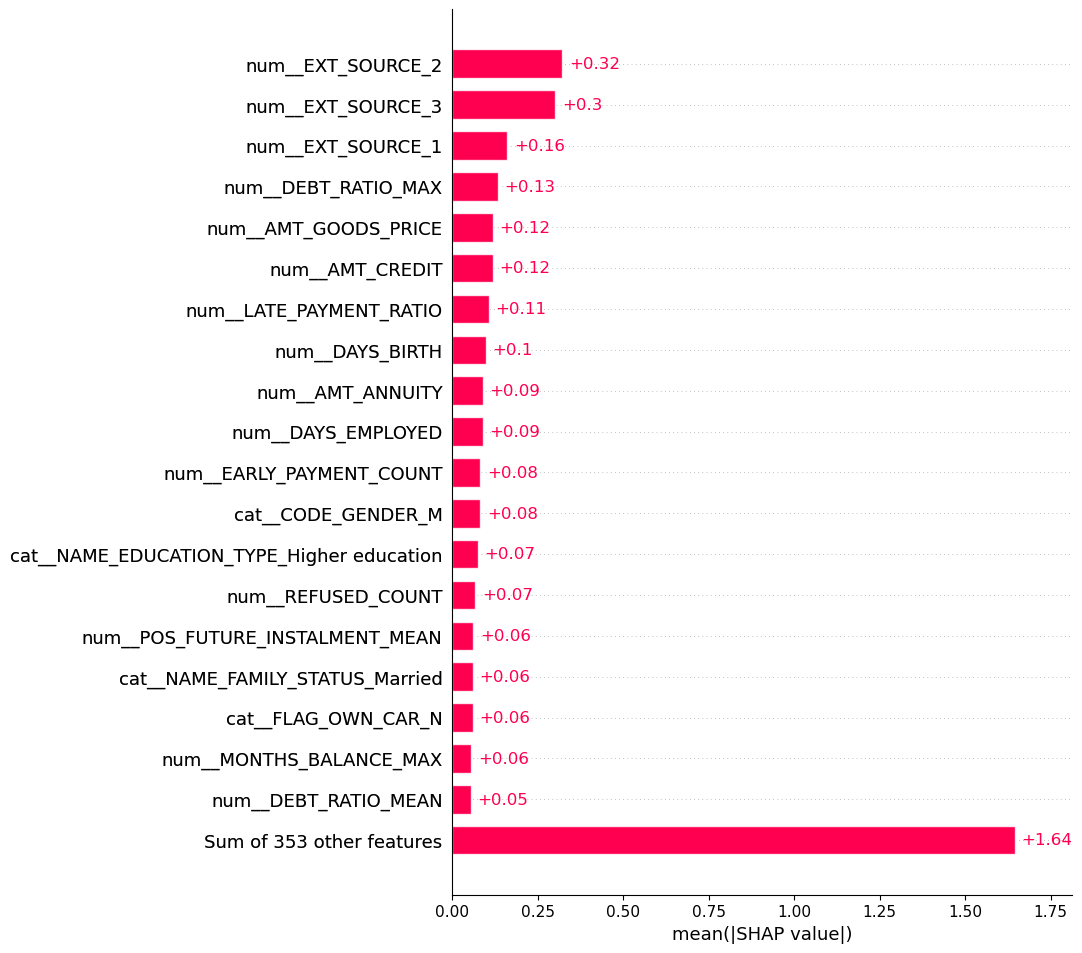

In [119]:
shap.plots.bar(
    shap_values,
    max_display=20
)

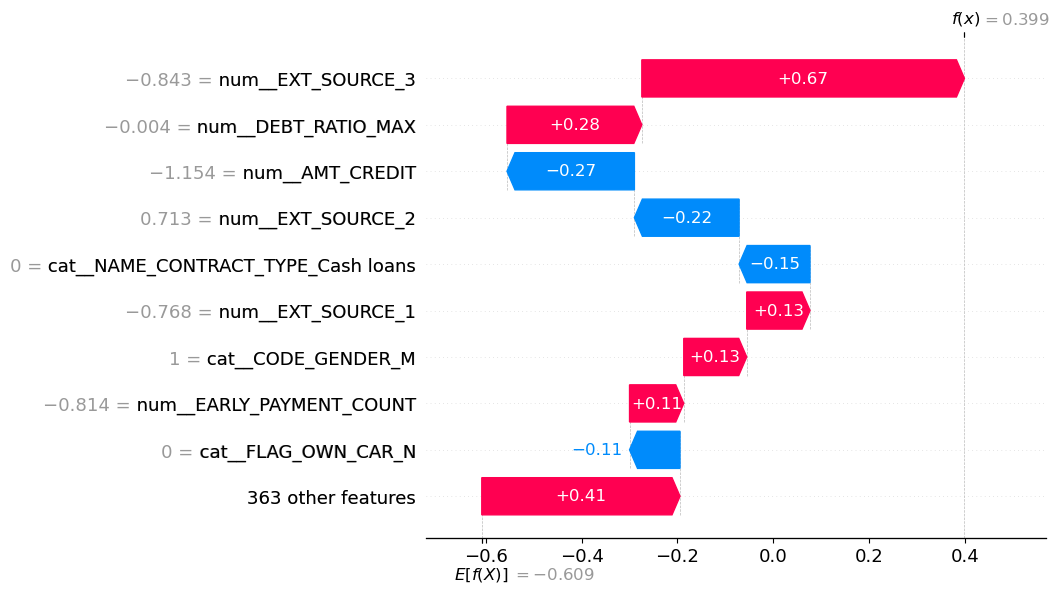

In [120]:
customer = 10

shap.plots.waterfall(
    shap_values[customer]
)

In [121]:
shap.initjs()

shap.plots.force(
    shap_values[customer]
)

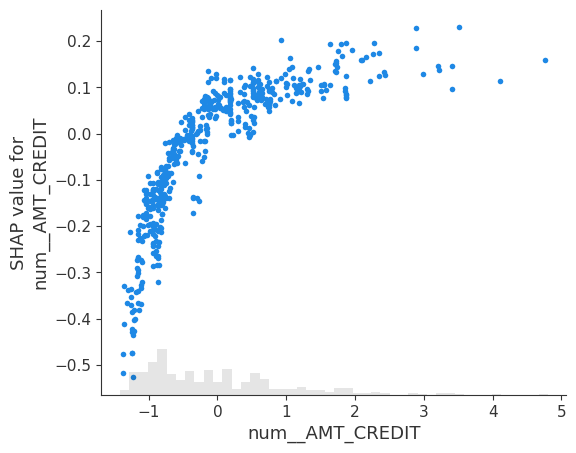

In [122]:
shap.plots.scatter(
    shap_values[:, "num__AMT_CREDIT"]
)

In [114]:
print(type(X_sample))

print(type(shap_values))

print(shap_values.shape)

print(X_sample.shape)

<class 'numpy.ndarray'>
<class 'shap._explanation.Explanation'>
(500, 372)
(500, 372)


In [126]:
feature_names_list = list(X_sample.columns)

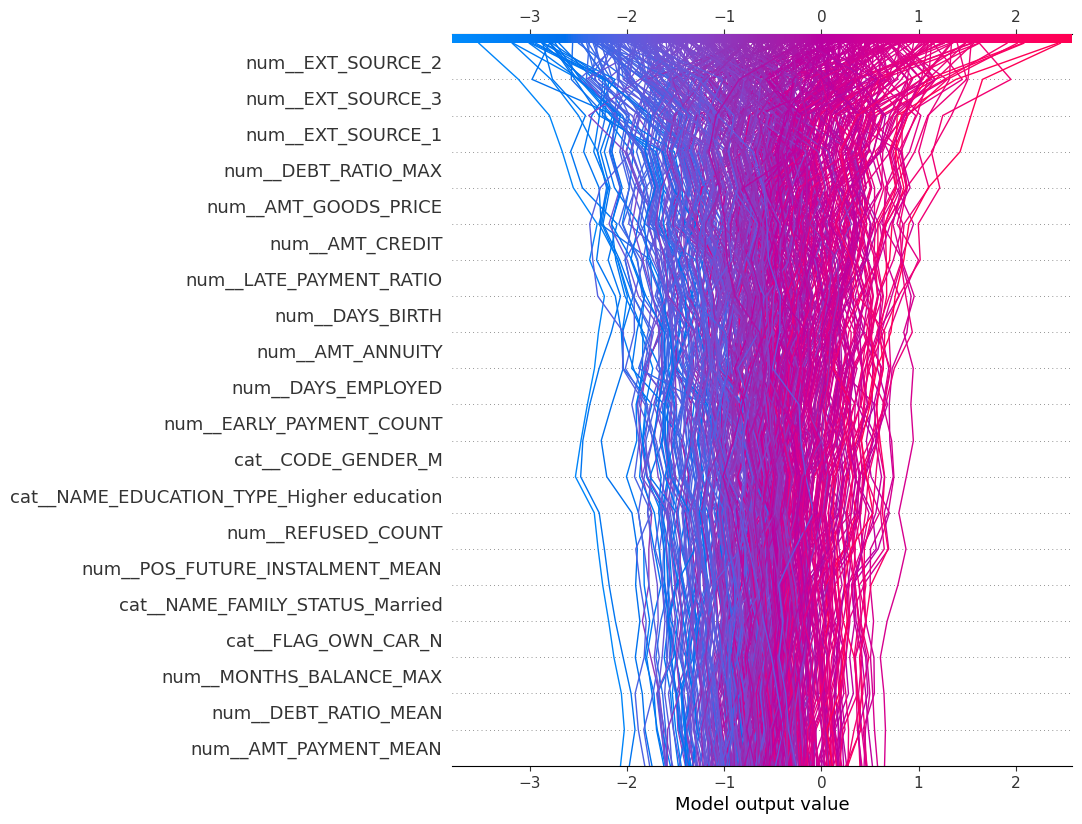

In [128]:
shap.decision_plot(
    explainer.expected_value,
    shap_values.values,
    feature_names=feature_names_list
)

In [129]:
import joblib

joblib.dump(
    best_lgbm,
    "../models/lightgbm_model.pkl"
)

print("LightGBM Model Saved")

LightGBM Model Saved


In [130]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Preprocessor Saved")

Preprocessor Saved


In [131]:
threshold = 0.65

joblib.dump(
    threshold,
    "../models/threshold.pkl"
)

print("Threshold Saved")

Threshold Saved
